In [44]:
import  pandas as  pd
import numpy as np
from sklearn.model_selection import  train_test_split

In [45]:
data=pd.read_csv("powerplant_data.csv")

In [46]:
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


| Variable | Full Form               | Meaning                                                |
| -------- | ----------------------- | ------------------------------------------------------ |
| **AT**   | Ambient Temperature     | Temperature of the surrounding air (°C)                |
| **V**    | Exhaust Vacuum          | Vacuum pressure of the turbine condenser (cm Hg)       |
| **AP**   | Ambient Pressure        | Atmospheric pressure around the power plant (millibar) |
| **RH**   | Relative Humidity       | Amount of moisture in the air (%)                      |
| **PE**   | Electrical Power Output | Power generated by the plant (MW)                      |


In [47]:
data.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [48]:
X=data.drop(columns="PE",axis=1)
Y=data["PE"]

## Stander Scaler

In [49]:
from sklearn.preprocessing  import StandardScaler
scaler=StandardScaler()
X_scale=scaler.fit_transform(X)

## Data is Split

In [50]:
x_train,x_test,y_train,y_test=train_test_split(X_scale,Y,test_size=0.2,random_state=42)

##  Tensors In Pytorch (Tensors is DataStructure)

In [51]:
import torch
import torch.nn as nn

In [52]:
x_train_torch=torch.tensor(x_train,dtype=torch.float32)
x_test_torch=torch.tensor(x_test,dtype=torch.float32)
y_test_torch=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)
y_train_torch=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

## DataSet and DataLoader

In [53]:
from torch.utils.data import TensorDataset,DataLoader

In [54]:
train_set=TensorDataset(x_train_torch,y_train_torch)
test_set=TensorDataset(x_test_torch,y_test_torch)

In [55]:
train_loader=DataLoader(train_set,batch_size=32,shuffle=True)
test_loader=DataLoader(test_set,batch_size=32)

# Deep Learning

## Building ANN Model

In [65]:
class ANN(nn.Module):
    def  __init__(self):
        # super(ANN,self).__init__()
        super().__init__()
        self.model=nn.Sequential(
            # 1.  hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
            #  2 hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
            # output  layer
            nn.Linear(6,1)       
        )
    def forward(self,x):
        return self.model(x)

In [66]:
model=ANN()
import  torch.optim  as optim
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

## Training the Model

In [68]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float running  loss is  calculating loss of one batch

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
    
    #Validation
    model.eval()
    running_val_loss=1.1
    with torch.no_grad():
        for  xb,yb in test_loader:
            output=model(xb)
            loss=crietrion(output,yb)
            running_val_loss+=loss
    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)
    print(f"epoch {epoch+1} /{epochs} ==> train loss = {epoch_train_loss} and val_loss={epoch_val_loss}")

    #Saving the model
    if epoch_val_loss< best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") # pt or pth"

epoch 1 /100 ==> train loss = 194340.61731770833 and val_loss=179805.28125
epoch 2 /100 ==> train loss = 154302.77451171874 and val_loss=124905.3046875
epoch 3 /100 ==> train loss = 93260.45276692709 and val_loss=65182.28515625
epoch 4 /100 ==> train loss = 45774.70517578125 and val_loss=32280.251953125
epoch 5 /100 ==> train loss = 25143.987080891926 and val_loss=20313.6328125
epoch 6 /100 ==> train loss = 17465.802473958334 and val_loss=15092.0986328125
epoch 7 /100 ==> train loss = 13283.020670572916 and val_loss=11488.974609375
epoch 8 /100 ==> train loss = 9954.513226318359 and val_loss=8363.09765625
epoch 9 /100 ==> train loss = 7080.069869995117 and val_loss=5765.28759765625
epoch 10 /100 ==> train loss = 4800.4059366861975 and val_loss=3889.85791015625
epoch 11 /100 ==> train loss = 3205.74859568278 and val_loss=2638.300048828125
epoch 12 /100 ==> train loss = 2172.532406107585 and val_loss=1833.1273193359375
epoch 13 /100 ==> train loss = 1520.8881360371909 and val_loss=1315.2

## Plot the Graph

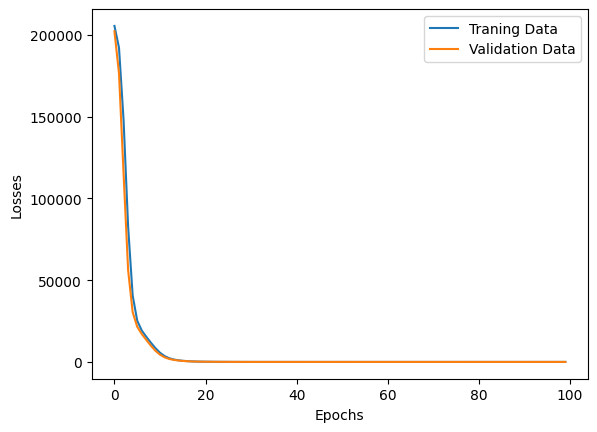

In [64]:
import matplotlib.pyplot as plt
loss_df=pd.DataFrame({
    "Traning Loss":train_losses,
                     "Validation Loss":val_losses
})
plt.plot(loss_df["Traning Loss"],label="Traning Data")
plt.plot(loss_df["Validation Loss"],label="Validation Data")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

## Loading the model

In [ ]:
model.load_state